## 08_seaborn

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторов, учитывайте только логи из table checker, где статус готов,

In [2]:
df = pd.read_sql(
    """
    SELECT uid, timestamp, numTrials
    FROM checker
    WHERE
        status = 'ready'
        AND uid LIKE 'user%'
         AND labname = 'project1'
            
    """,
    conn,
    parse_dates="timestamp",
)
df

,uid,timestamp,numTrials
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5
...,...,...,...
946,user_19,2020-05-15 10:22:39.698523,26
947,user_19,2020-05-15 10:22:46.248162,27
948,user_19,2020-05-15 10:23:18.043212,28
949,user_28,2020-05-15 10:38:14.430013,27


### вы можете выбрать ту палитру, которая вам нравится, ширина линии должна быть равна 3, фон графика серый, высота должна быть 10, а ширина должна быть в 1,5 раза больше высоты, размер шрифта заголовка должен быть 30, размер шрифта надписей axises равен 15

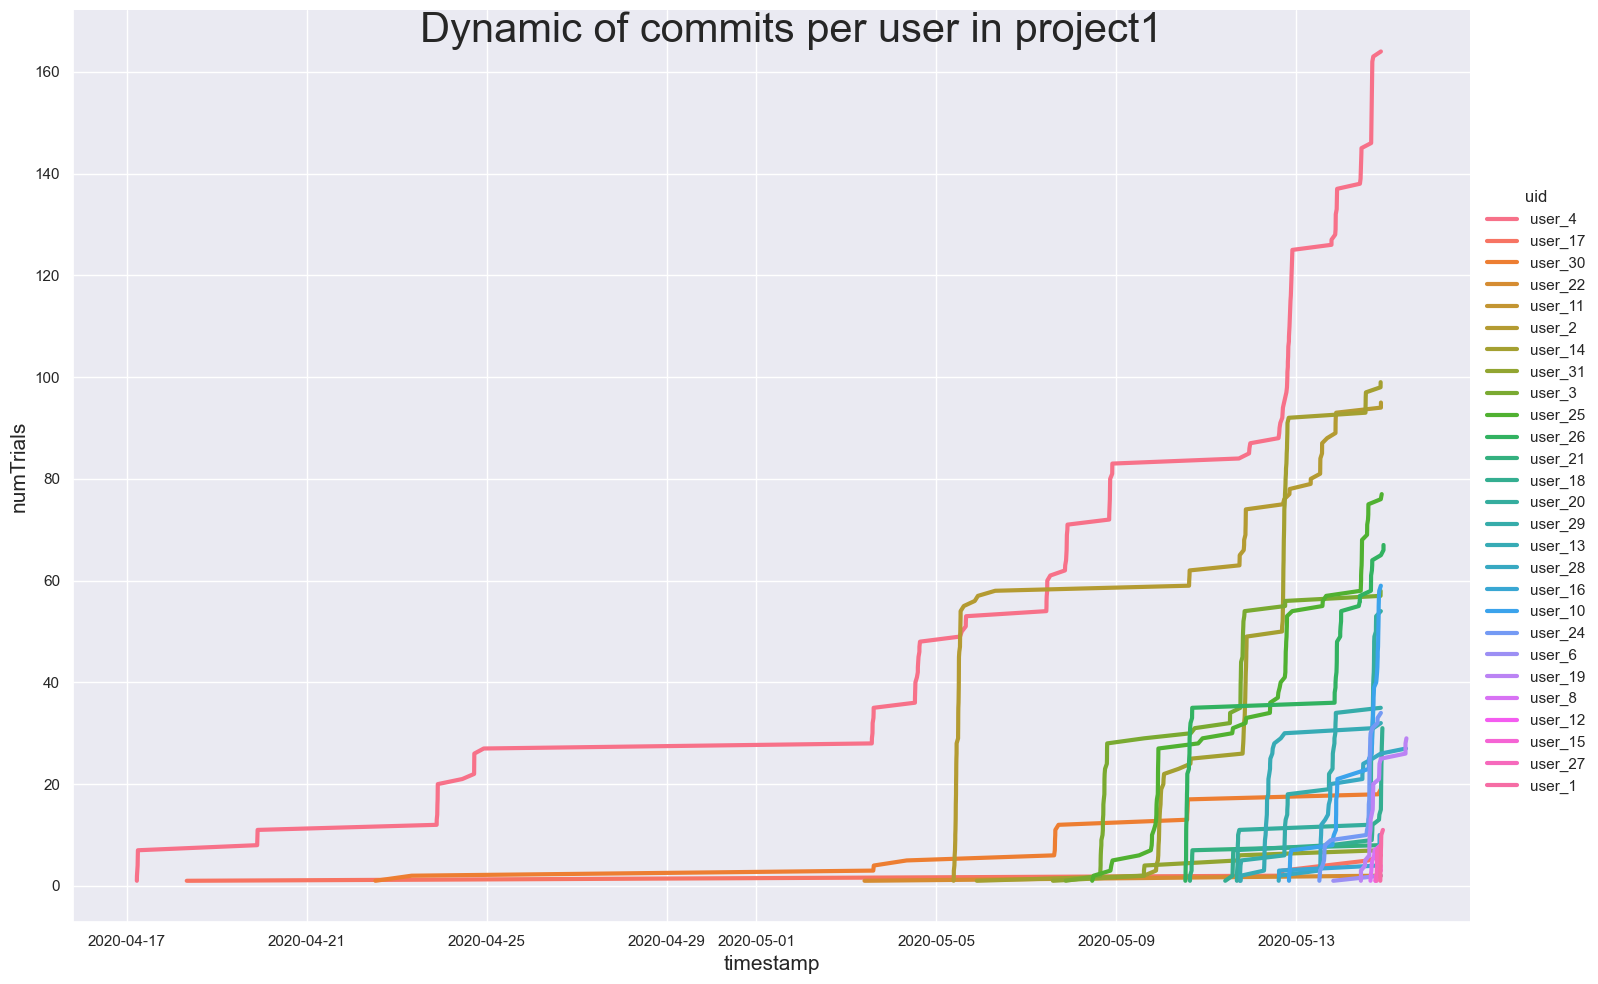

In [3]:
sns.set_theme(palette="deep", rc={"axes.labelsize": 15, "lines.linewidth": 3})
sns.relplot(
    data=df,
    x="timestamp",
    y="numTrials",
    legend="full",
    hue="uid",
    kind="line",
    height=10,
    aspect=1.5,
)
plt.suptitle("Dynamic of commits per user in project1", fontsize=30)
plt.show()

### Какой пользователь почти всё время лидировал по количеству коммитов? Ответ - user_4.

### Какой пользователь был лидером лишь в течение короткого периода времени? Ответ - user_2.

In [4]:
conn.close()